In [ ]:
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import unique
from pandas import read_csv
import seaborn as sns
sns.set(style='ticks')
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [ ]:
url = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
df = read_csv(url)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


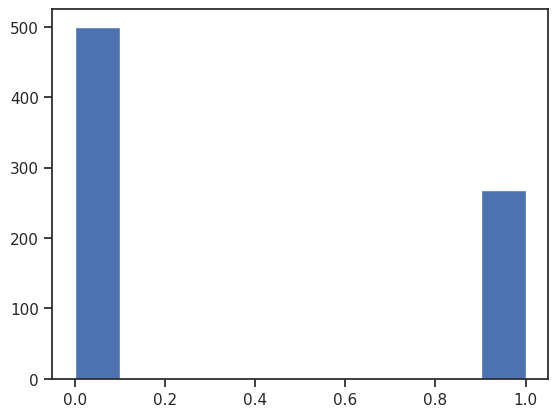

In [ ]:
plt.hist(df['Outcome'])
plt.show()

# Memisahkan Label dan Feature

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Membagi Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(f"Train-test split: train={len(X_train)}, test={len(X_test)}")

Train-test split: train=614, test=154


# Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

# Imbalance

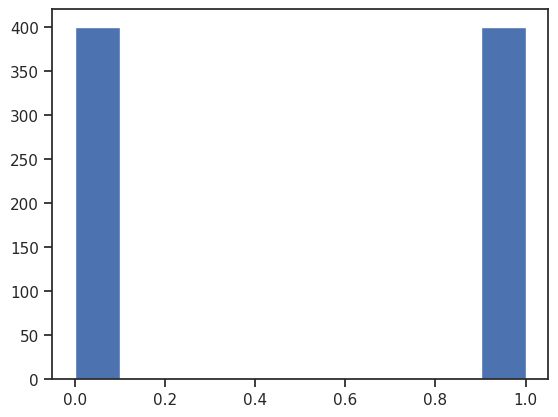

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train_scaled, y_train)

X_smote = pd.DataFrame(X_smote_resampled, columns=X.columns)
y_smote = pd.DataFrame(y_smote_resampled, columns=[y.name])

df_balanced = pd.concat([X_smote, y_smote], axis=1)
df_balanced.head()
plt.hist(df_balanced['Outcome'])
plt.show()

# Seleksi Fitur

HASIL SELEKSI FITUR
                   Fitur       Skor
                 Glucose 184.605203
                     BMI  72.732991
                     Age  57.797882
             Pregnancies  55.076783
DiabetesPedigreeFunction  25.000929
                 Insulin  18.632883
           SkinThickness   5.748681
           BloodPressure   2.308821


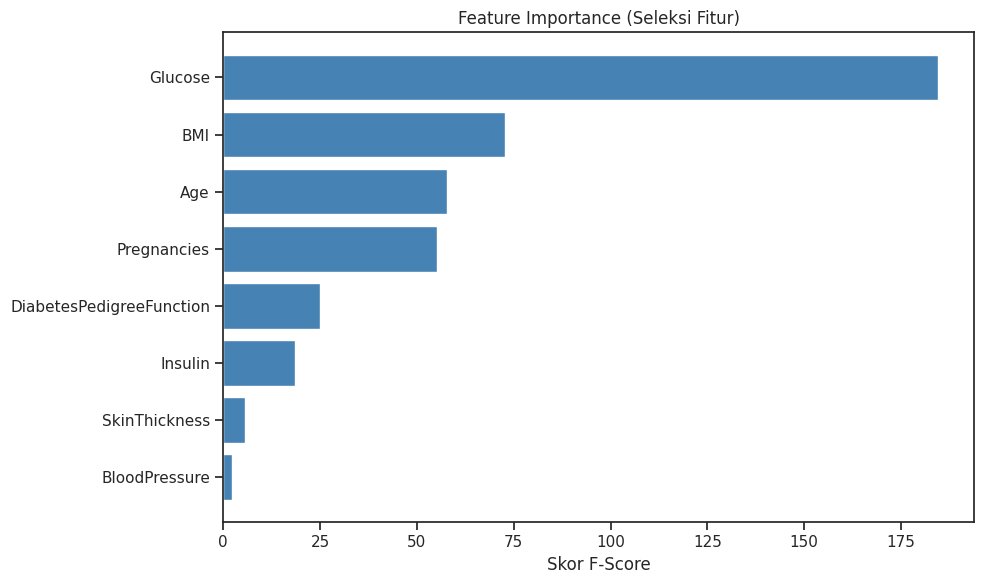

REKOMENDASI FITUR TERBAIK
1 Fitur Terbaik: Glucose
3 Fitur Terbaik: ['Glucose', 'BMI', 'Age']
5 Fitur Terbaik: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']
Semua Fitur (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import matplotlib.pyplot as plt

# Seleksi fitur dengan ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_smote, y_smote.values.ravel())

# Hasil skor setiap fitur
scores = pd.DataFrame({
    'Fitur': X.columns,
    'Skor': selector.scores_
}).sort_values('Skor', ascending=False)

print("HASIL SELEKSI FITUR")
print(scores.to_string(index=False))

# Visualisasi feature importance
plt.figure(figsize=(10, 6))
plt.barh(scores['Fitur'], scores['Skor'], color='steelblue')
plt.xlabel('Skor F-Score')
plt.title('Feature Importance (Seleksi Fitur)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("REKOMENDASI FITUR TERBAIK")

top1 = scores.iloc[0]['Fitur']
top3 = scores.iloc[:3]['Fitur'].tolist()
top5 = scores.iloc[:5]['Fitur'].tolist()

print(f"1 Fitur Terbaik: {top1}")
print(f"3 Fitur Terbaik: {top3}")
print(f"5 Fitur Terbaik: {top5}")
print(f"Semua Fitur (8): {list(X.columns)}")

# HPO Algoritma Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

classifier_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid_dt,
    scoring='recall_macro',
    cv=5,
    refit=True,
    verbose=3
)

classifier_dt.fit(X_smote, y_smote)

print('Parameter terbaik:', classifier_dt.best_params_)
print(classifier_dt.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.694 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.700 total time=   0.1s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.669 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.812 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.750 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.681 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.725 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.675 total time=  

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       100
           1       0.68      0.67      0.67        54

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



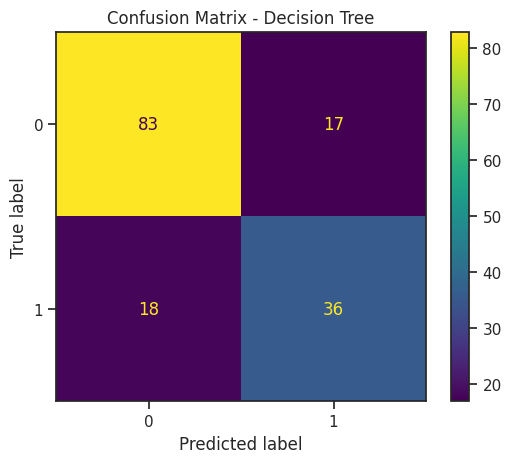

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_dt = classifier_dt.predict(X_test_scaled)

print(classification_report(y_test, pred_dt))

cm_dt = confusion_matrix(y_test, pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()

# HPO Algoritma NN

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': [1000, 1500, 2000, 3000]
}

classifier_mlp = GridSearchCV(
    MLPClassifier(random_state=0, early_stopping=True, validation_fraction=0.1),
    param_grid_mlp,
    scoring='recall_macro',
    cv=5,
    refit=True,
    verbose=3
)

if y_smote.ndim > 1:
    y_smote_1d = y_smote.values.ravel()
else:
    y_smote_1d = y_smote

classifier_mlp.fit(X_smote, y_smote_1d)

print('Parameter terbaik:', classifier_mlp.best_params_)
print(classifier_mlp.best_estimator_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.700 total time=   0.1s
[CV 2/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.675 total time=   0.1s
[CV 3/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.775 total time=   0.1s
[CV 4/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.738 total time=   0.1s
[CV 5/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.731 total time=   0.1s
[CV 1/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.512 total time=   0.0s
[CV 2/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.575 total time=   0.0s
[CV 3/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.700 total time=   0.1s
[CV 4/5] END 

              precision    recall  f1-score   support

           0       0.87      0.77      0.81       100
           1       0.65      0.78      0.71        54

    accuracy                           0.77       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.79      0.77      0.78       154



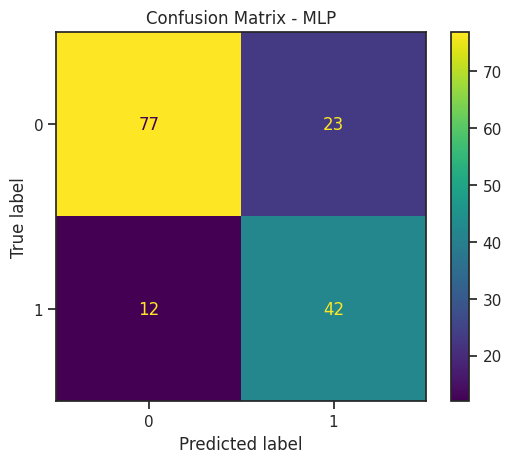

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_mlp = classifier_mlp.predict(X_test_scaled)

print(classification_report(y_test, pred_mlp))

cm_mlp = confusion_matrix(y_test, pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp_mlp.plot()
plt.title('Confusion Matrix - MLP')
plt.show()

# Save Model

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

dt_filename = '/content/Tubes_Dasildat_DecisionTree.sav'
joblib.dump(classifier_dt.best_estimator_, dt_filename)

loaded_dt = joblib.load(dt_filename)
print(loaded_dt)

print('Hail model menggunakan yang sudah di simpan:', loaded_dt.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_dt.score(X_test_scaled, y_test))

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=0)
Hail model menggunakan yang sudah di simpan: 0.7727272727272727
Hail model menggunakan hasil training lansung: 0.7483333333333333


In [ ]:
import joblib

data_filename = '/content/Tubes_Dasildat_NN.sav'
joblib.dump(classifier_mlp.best_estimator_, data_filename)

loaded_mlp = joblib.load(data_filename)
print(loaded_mlp)

print('Hail model menggunakan yang sudah di simpan:', loaded_mlp.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_mlp.score(X_test_scaled, y_test))

MLPClassifier(early_stopping=True, max_iter=1000, random_state=0)
Hail model menggunakan yang sudah di simpan: 0.7727272727272727
Hail model menggunakan hasil training lansung: 0.7738888888888888


In [ ]:
import joblib

scaler_filename = '/content/Tubes_Dasildat_Scaler.sav'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

Scaler saved to /content/Tubes_Dasildat_Scaler.sav


# Perbandingan Akurasi Model

=== Perbandingan Performa Model ===
                 Model  Accuracy  Precision  Recall  F1-Score
Ranking                                                      
1        Decision Tree    0.7727     0.7505  0.7483    0.7494
2                  MLP    0.7727     0.7557  0.7739    0.7603


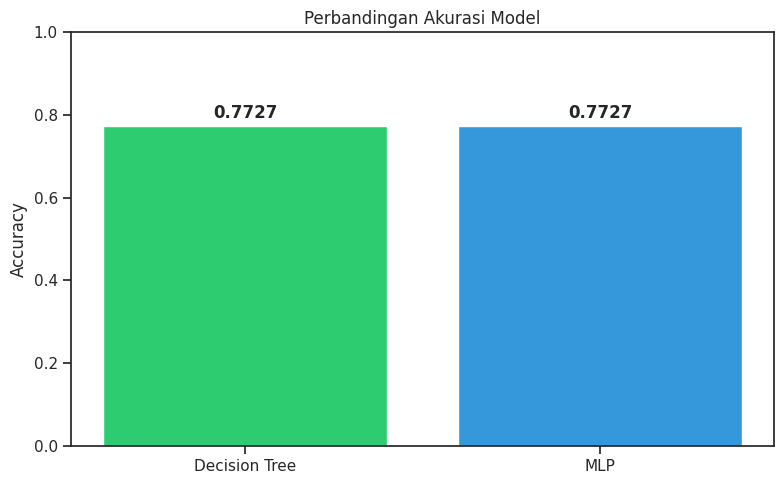


Model terbaik: Decision Tree dengan akurasi 0.7727


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

pred_dt   = classifier_dt.predict(X_test_scaled)
pred_mlp  = classifier_mlp.predict(X_test_scaled)

# Hitung metrik
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='macro'), 4),
    }

results = [
    get_metrics(y_test, pred_dt,   'Decision Tree'),
    get_metrics(y_test, pred_mlp,  'MLP'),
]

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1  # ranking mulai dari 1
df_results.index.name = 'Ranking'

print('=== Perbandingan Performa Model ===')
print(df_results.to_string())

# Bar chart perbandingan akurasi
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = ax.bar(df_results['Model'], df_results['Accuracy'], color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi Model')
for bar, val in zip(bars, df_results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

best = df_results.iloc[0]
print(f"\nModel terbaik: {best['Model']} dengan akurasi {best['Accuracy']}")

# Download File

In [ ]:
from google.colab import files

# files.download('/content/Tubes_Dasildat_SVM.sav')
# files.download('/content/Tubes_Dasildat_KNN.sav')
# files.download('/content/Tubes_Dasildat_DecisionTree.sav')
files.download('/content/Tubes_Dasildat_NN.sav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download scaler
# files.download('/content/Tubes_Dasildat_Scaler.sav') # This line caused an error because the scaler was not saved.

In [ ]:
# from google.colab import files

# # Download scaler
# files.download('/content/Tubes_Dasildat_Scaler.sav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>